In [1]:
import pandas as pd

In [2]:
try:
    df=pd.read_csv("loan_detection.csv")
    print("Dataset loaded successfully.")
    print(f"Original shape of data: {df.shape}")
except FileNotFoundError:
    print("File not found")
    exit()

Dataset loaded successfully.
Original shape of data: (41188, 60)


In [3]:
original_columns=df.columns.tolist()
df.columns = df.columns.str.replace('.','_',regex=False)
print("\n Standardizing column names...")


 Standardizing column names...


In [5]:
num_duplicates_before = df.duplicated().sum()
print(f"\nFound {num_duplicates_before} duplicate rows.")


Found 2417 duplicate rows.


In [6]:
if num_duplicates_before >0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows have been removed.")
    print(f"Shape of the data bafter removing duplicates: {df.shape}")
else:
    print("No duplicate rows to remove.")


Duplicate rows have been removed.
Shape of the data bafter removing duplicates: (38771, 60)


In [7]:
missing_values = df.isnull().sum().sum()
print(f"\n Found {missing_values} missing (NaN) values.")


 Found 0 missing (NaN) values.


In [8]:
if missing_values ==0:
    print("Your dataset has no missing values.")

Your dataset has no missing values.


In [9]:
print(f"Final shape of the cleaned data: {df.shape}")

Final shape of the cleaned data: (38771, 60)


In [12]:
cleaned_file_name="loan_detection.csv"
df.to_csv(cleaned_file_name,index= False)
print(f"cleaned data saved to '{cleaned_file_name}'")

cleaned data saved to 'loan_detection.csv'


In [13]:
print(df.head())
import pandas as pd 
from sklearn.model_selection import train_test_split

   age  campaign  pdays  previous  no_previous_contact  not_working  \
0   56         1    999         0                    1            0   
1   57         1    999         0                    1            0   
2   37         1    999         0                    1            0   
3   40         1    999         0                    1            0   
4   56         1    999         0                    1            0   

   job_admin_  job_blue-collar  job_entrepreneur  job_housemaid  ...  \
0           0                0                 0              1  ...   
1           0                0                 0              0  ...   
2           0                0                 0              0  ...   
3           1                0                 0              0  ...   
4           0                0                 0              0  ...   

   month_sep  day_of_week_fri  day_of_week_mon  day_of_week_thu  \
0          0                0                1                0   
1     

In [16]:
df=pd.read_csv("loan_detection.csv")

In [17]:
x=df.drop("Loan_Status_label",axis=1)
y=df["Loan_Status_label"]

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
print("Data preprocessing complete.")
print(f"Training set shape: {x_train.shape}")
print(f"Training set shape: {x_test.shape}")

Data preprocessing complete.
Training set shape: (31016, 59)
Training set shape: (7755, 59)


In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train,y_train)

C:\Users\kumar\anaconda3\envs\learning_phase\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [25]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
random_forest=RandomForestClassifier(n_estimators=100,random_state=42)
random_forest.fit(x_train,y_train)
print("Random Forest model trained successfully")

Random Forest model trained successfully


In [30]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:

y_pred_log_reg=log_reg.predict(x_test)
print("Accuracy: ", accuracy_score(y_test,y_pred_log_reg))
print("\nClassification Report:\n",classification_report(y_test,y_pred_log_reg))

Accuracy:  0.8977433913604126

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.94      6894
           1       0.64      0.18      0.28       861

    accuracy                           0.90      7755
   macro avg       0.77      0.58      0.61      7755
weighted avg       0.88      0.90      0.87      7755



In [35]:
y_pred_rf=random_forest.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("\nclassification Reprot:\n",classification_report(y_test,y_pred_rf))
    

Accuracy: 0.883043197936815

classification Reprot:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94      6894
           1       0.45      0.23      0.31       861

    accuracy                           0.88      7755
   macro avg       0.68      0.60      0.62      7755
weighted avg       0.86      0.88      0.87      7755



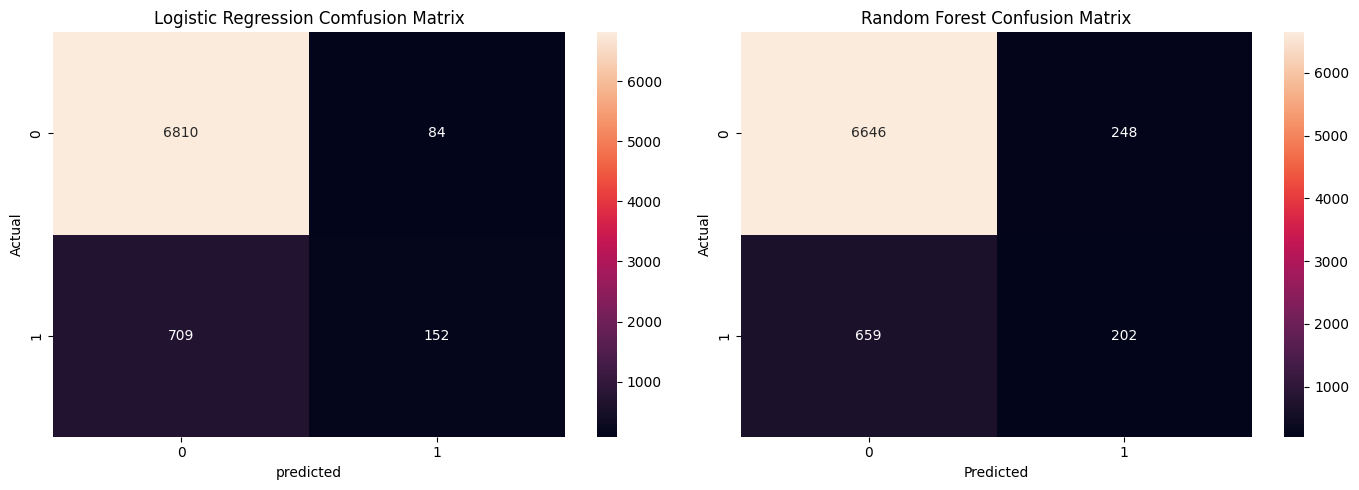

In [40]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.heatmap(confusion_matrix(y_test,y_pred_log_reg), annot=True,fmt="d",ax=ax[0])
ax[0].set_title("Logistic Regression Comfusion Matrix")
ax[0].set_xlabel("predicted")
ax[0].set_ylabel("Actual")
sns.heatmap(confusion_matrix(y_test,y_pred_rf),annot=True,fmt="d",ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [43]:
importances=random_forest.feature_importances_
feature_names=x.columns
feature_importance_df=pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance",ascending=False)

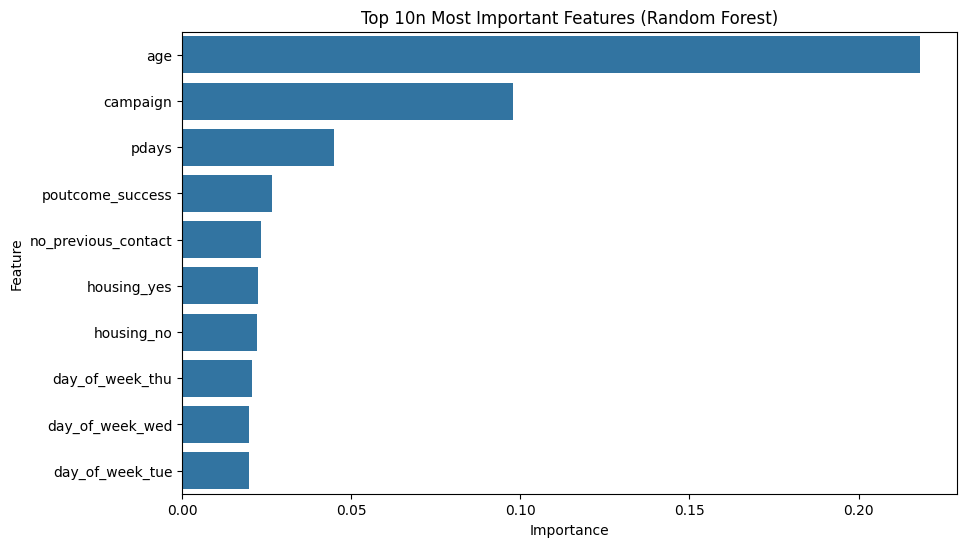

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance",y="Feature",data=feature_importance_df.head(10))
plt.title("Top 10n Most Important Features (Random Forest)")
plt.show()